# Week 1 Lab Assignment — Natural Language Processing (CSET346)

**Course:** B.Tech. NLP (Lab) | **Type:** Specialization / NSPL Elective-I
**Date:** 17/08/2026 – 21/08/2026

This notebook covers **Task 1** (environment familiarization: reading/visualizing
many data formats) and **Task 2** (text data cleaning + tokenization, frequency
analysis, stemming and lemmatization) from `2026_ODD_Week_1_Assignment_Intro.pdf`.

> **Note on Task 1 data:** rather than depending on live internet downloads
> (which are unreliable to re-run and grade), representative sample files for
> each format are **generated locally** inside this notebook, then read back
> and visualized exactly as required by the assignment steps 2–4. This keeps
> the notebook fully reproducible offline.


In [1]:
import os
os.makedirs("data", exist_ok=True)
print("Working directory ready:", os.path.abspath("data"))

Working directory ready: /Users/swapnil/Documents/NLP/week1/data


## Task 1 — Getting Familiar with the Environment

Popular NLP/data libraries (`nltk`, `re`, `spaCy`), data types, and visualization across tabular, spreadsheet, interchange, binary, image, video, audio and text data formats.

### 1. Tabular / Interchange Data Formats — `.dat`, `.csv`, `.tsv`, `.arff`

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 50
df_tabular = pd.DataFrame({
    "id": range(1, n + 1),
    "category": np.random.choice(list("ABCD"), n),
    "score": np.round(np.random.normal(70, 12, n), 2),
    "hours_studied": np.round(np.random.uniform(1, 10, n), 1),
})

# .dat (generic tabular, whitespace-separated)
df_tabular.to_csv("data/sample.dat", sep=" ", index=False)
# .csv
df_tabular.to_csv("data/sample.csv", index=False)
# .tsv
df_tabular.to_csv("data/sample.tsv", sep="\t", index=False)

print("Wrote sample.dat, sample.csv, sample.tsv")

Wrote sample.dat, sample.csv, sample.tsv


In [3]:
# Read each format back
df_dat = pd.read_csv("data/sample.dat", sep=" ")
df_csv = pd.read_csv("data/sample.csv")
df_tsv = pd.read_csv("data/sample.tsv", sep="\t")

for name, d in [(".dat", df_dat), (".csv", df_csv), (".tsv", df_tsv)]:
    print(f"--- {name} ---  shape={d.shape}, size={d.size}, dims={d.ndim}")
df_csv.head()

--- .dat ---  shape=(50, 4), size=200, dims=2
--- .csv ---  shape=(50, 4), size=200, dims=2
--- .tsv ---  shape=(50, 4), size=200, dims=2


,id,category,score,hours_studied
0,1,C,62.45,5.4
1,2,D,77.17,5.7
2,3,A,100.71,4.8
3,4,C,74.73,1.2
4,5,C,71.47,2.0


In [4]:
# .arff (Attribute-Relation File Format)
import arff  # liac-arff

arff_data = {
    "description": "Sample tabular dataset in ARFF format",
    "relation": "sample_scores",
    "attributes": [
        ("id", "NUMERIC"),
        ("category", ["A", "B", "C", "D"]),
        ("score", "NUMERIC"),
        ("hours_studied", "NUMERIC"),
    ],
    "data": df_tabular.values.tolist(),
}
with open("data/sample.arff", "w") as f:
    arff.dump(arff_data, f)

with open("data/sample.arff") as f:
    loaded_arff = arff.load(f)

df_arff = pd.DataFrame(loaded_arff["data"], columns=[a[0] for a in loaded_arff["attributes"]])
print("ARFF relation:", loaded_arff["relation"])
print("shape:", df_arff.shape, "attributes:", loaded_arff["attributes"])
df_arff.head()

ARFF relation: sample_scores
shape: (50, 4) attributes: [('id', 'NUMERIC'), ('category', ['A', 'B', 'C', 'D']), ('score', 'NUMERIC'), ('hours_studied', 'NUMERIC')]


,id,category,score,hours_studied
0,1.0,C,62.45,5.4
1,2.0,D,77.17,5.7
2,3.0,A,100.71,4.8
3,4.0,C,74.73,1.2
4,5.0,C,71.47,2.0


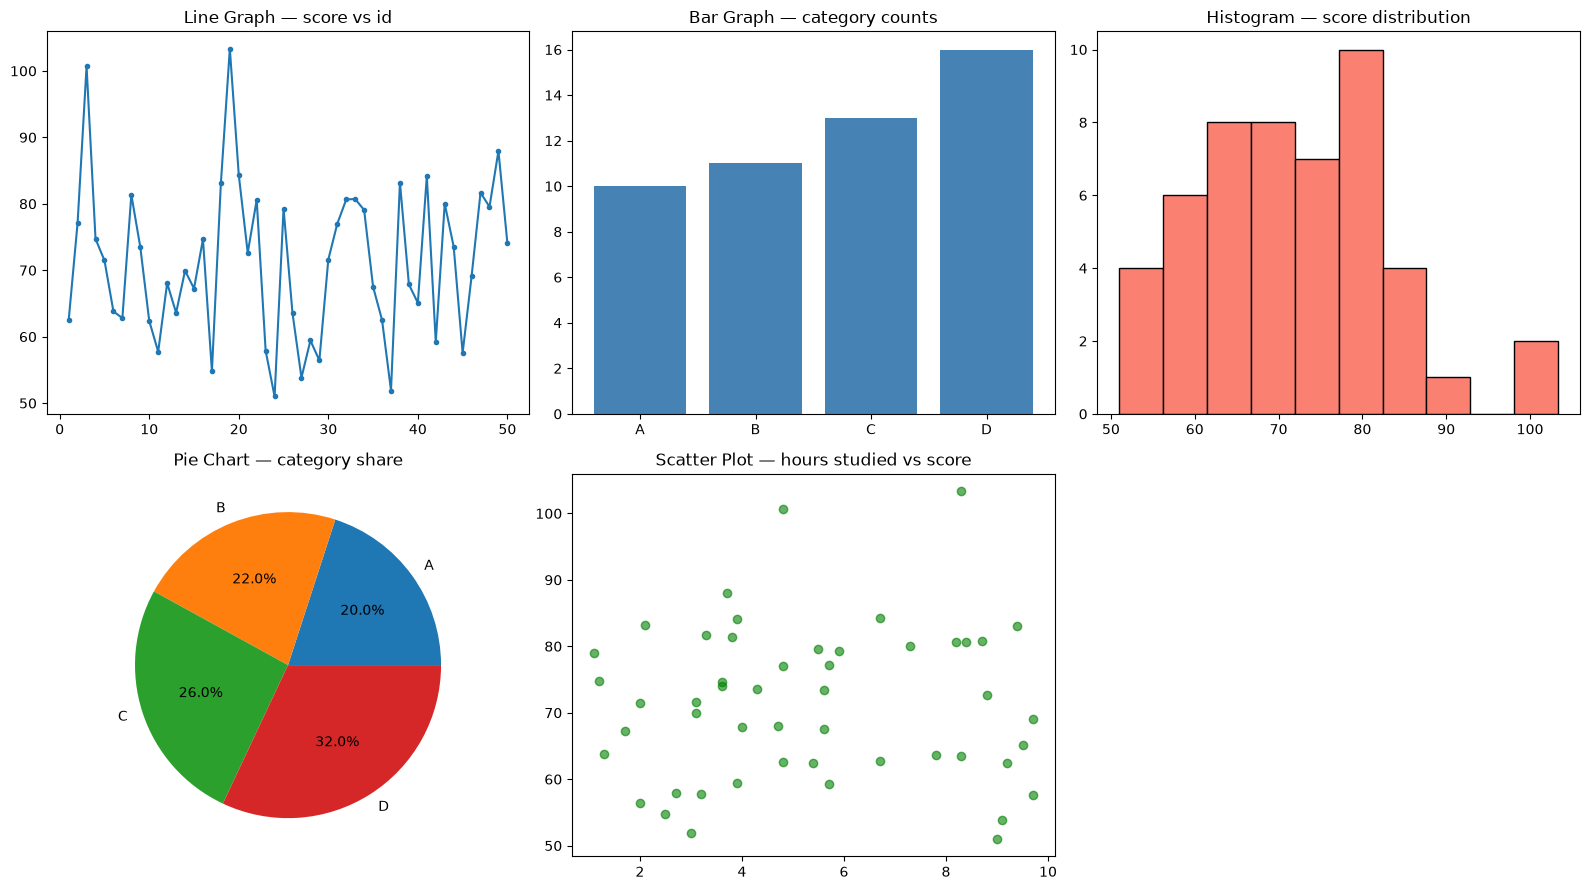

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Line graph
axes[0, 0].plot(df_csv["id"], df_csv["score"], marker="o", ms=3)
axes[0, 0].set_title("Line Graph — score vs id")

# Bar graph
cat_counts = df_csv["category"].value_counts().sort_index()
axes[0, 1].bar(cat_counts.index, cat_counts.values, color="steelblue")
axes[0, 1].set_title("Bar Graph — category counts")

# Histogram
axes[0, 2].hist(df_csv["score"], bins=10, color="salmon", edgecolor="black")
axes[0, 2].set_title("Histogram — score distribution")

# Pie chart
axes[1, 0].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%")
axes[1, 0].set_title("Pie Chart — category share")

# Scatter plot
axes[1, 1].scatter(df_csv["hours_studied"], df_csv["score"], c="green", alpha=0.6)
axes[1, 1].set_title("Scatter Plot — hours studied vs score")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

### 2. Spreadsheet Data Formats — `.xlsx`, `.ods`

`.xls` (legacy binary Excel <=2003) and the very old `.sxc` / `.dif` formats have no actively maintained *write* libraries in modern Python (`xlwt` is unmaintained and does not support Python 3.13). We read/write the two formats that remain fully supported — `.xlsx` via `openpyxl` and `.ods` via `odfpy` — and note this limitation instead of producing broken/unreadable legacy files.

In [6]:
# .xlsx
df_tabular.to_excel("data/sample.xlsx", index=False, engine="openpyxl")
df_xlsx = pd.read_excel("data/sample.xlsx", engine="openpyxl")
print(".xlsx shape:", df_xlsx.shape)
df_xlsx.head()

.xlsx shape: (50, 4)


,id,category,score,hours_studied
0,1,C,62.45,5.4
1,2,D,77.17,5.7
2,3,A,100.71,4.8
3,4,C,74.73,1.2
4,5,C,71.47,2.0


In [7]:
# .ods (OpenDocument Spreadsheet)
df_tabular.to_excel("data/sample.ods", index=False, engine="odf")
df_ods = pd.read_excel("data/sample.ods", engine="odf")
print(".ods shape:", df_ods.shape)
df_ods.head()

.ods shape: (50, 4)


,id,category,score,hours_studied
0,1,C,62.45,5.4
1,2,D,77.17,5.7
2,3,A,100.71,4.8
3,4,C,74.73,1.2
4,5,C,71.47,2.0


### 3. Interchange Formats — `.json`, `.ubjson`, `.html`, `.xml`

In [8]:
import json, ubjson

record = {
    "dataset": "sample_scores",
    "n_records": int(len(df_tabular)),
    "records": df_tabular.to_dict(orient="records")[:5],
}

# JSON
with open("data/sample.json", "w") as f:
    json.dump(record, f, indent=2)
with open("data/sample.json") as f:
    loaded_json = json.load(f)
print("JSON keys:", list(loaded_json.keys()), "| records loaded:", len(loaded_json["records"]))

# UBJSON (binary JSON)
with open("data/sample.ubj", "wb") as f:
    ubjson.dump(record, f)
with open("data/sample.ubj", "rb") as f:
    loaded_ubj = ubjson.load(f)
print("UBJSON file size (bytes):", os.path.getsize("data/sample.ubj"), "| decoded OK:", loaded_ubj == record)

JSON keys: ['dataset', 'n_records', 'records'] | records loaded: 5
UBJSON file size (bytes): 351 | decoded OK: True


In [9]:
# HTML
html_str = df_tabular.head(10).to_html(index=False)
with open("data/sample.html", "w") as f:
    f.write(f"<html><body><h2>Sample Scores</h2>{html_str}</body></html>")

parsed_tables = pd.read_html("data/sample.html")
print("Tables parsed from HTML:", len(parsed_tables))
parsed_tables[0].head()

Tables parsed from HTML: 1


,id,category,score,hours_studied
0,1,C,62.45,5.4
1,2,D,77.17,5.7
2,3,A,100.71,4.8
3,4,C,74.73,1.2
4,5,C,71.47,2.0


In [10]:
# XML
from lxml import etree

root = etree.Element("dataset", name="sample_scores")
for _, row in df_tabular.head(10).iterrows():
    rec = etree.SubElement(root, "record")
    for col, val in row.items():
        etree.SubElement(rec, col).text = str(val)
tree = etree.ElementTree(root)
tree.write("data/sample.xml", pretty_print=True, xml_declaration=True, encoding="UTF-8")

parsed_xml = etree.parse("data/sample.xml")
records = parsed_xml.findall("record")
print("XML records parsed:", len(records))
print("First record fields:", [child.tag for child in records[0]])

XML records parsed: 10
First record fields: ['id', 'category', 'score', 'hours_studied']


### 4. Data File Formats — `.pkl`, `.h5` (HDF5), `.zip`, `.sql`, `.mat`, `.npy`, `.npz`

In [11]:
import pickle

# PKL
with open("data/sample.pkl", "wb") as f:
    pickle.dump(df_tabular, f)
with open("data/sample.pkl", "rb") as f:
    df_pkl = pickle.load(f)
print(".pkl shape:", df_pkl.shape)

.pkl shape: (50, 4)


In [12]:
import h5py

# HDF5
with h5py.File("data/sample.h5", "w") as f:
    f.create_dataset("score", data=df_tabular["score"].values)
    f.create_dataset("hours_studied", data=df_tabular["hours_studied"].values)

with h5py.File("data/sample.h5", "r") as f:
    print(".h5 datasets:", list(f.keys()))
    print("score shape:", f["score"].shape, "dtype:", f["score"].dtype)
    h5_score = f["score"][:]
print("first 5 values:", h5_score[:5])

.h5 datasets: ['hours_studied', 'score']
score shape: (50,) dtype: float64
first 5 values: [ 62.45  77.17 100.71  74.73  71.47]


In [13]:
import zipfile

# ZIP
with zipfile.ZipFile("data/sample.zip", "w") as zf:
    zf.write("data/sample.csv", arcname="sample.csv")
    zf.write("data/sample.json", arcname="sample.json")

with zipfile.ZipFile("data/sample.zip", "r") as zf:
    print(".zip contents:", zf.namelist())
    print("info:", [(i.filename, i.file_size) for i in zf.infolist()])

.zip contents: ['sample.csv', 'sample.json']
info: [('sample.csv', 769), ('sample.json', 571)]


In [14]:
import sqlite3

# SQL (SQLite database file)
conn = sqlite3.connect("data/sample.sql")
df_tabular.to_sql("scores", conn, if_exists="replace", index=False)
df_sql = pd.read_sql("SELECT * FROM scores LIMIT 10", conn)
conn.close()
print(".sql (sqlite) shape read back:", df_sql.shape)
df_sql.head()

.sql (sqlite) shape read back: (10, 4)


,id,category,score,hours_studied
0,1,C,62.45,5.4
1,2,D,77.17,5.7
2,3,A,100.71,4.8
3,4,C,74.73,1.2
4,5,C,71.47,2.0


In [15]:
from scipy.io import savemat, loadmat

# MAT (MATLAB)
savemat("data/sample.mat", {
    "score": df_tabular["score"].values,
    "hours_studied": df_tabular["hours_studied"].values,
})
mat_data = loadmat("data/sample.mat")
print(".mat keys:", [k for k in mat_data if not k.startswith("__")])
print("score shape:", mat_data["score"].shape)

.mat keys: ['score', 'hours_studied']
score shape: (1, 50)


In [16]:
# NPY / NPZ
arr = df_tabular["score"].values
np.save("data/sample.npy", arr)
np.savez("data/sample.npz", score=df_tabular["score"].values, hours=df_tabular["hours_studied"].values)

loaded_npy = np.load("data/sample.npy")
loaded_npz = np.load("data/sample.npz")
print(".npy shape:", loaded_npy.shape, "dtype:", loaded_npy.dtype)
print(".npz arrays:", loaded_npz.files, "| score shape:", loaded_npz["score"].shape)

.npy shape: (50,) dtype: float64
.npz arrays: ['score', 'hours'] | score shape: (50,)


### 5. Image Data Formats — `.jpg`, `.png`, `.bmp`, `.tiff`, DICOM (`.dcm`), `.mha`

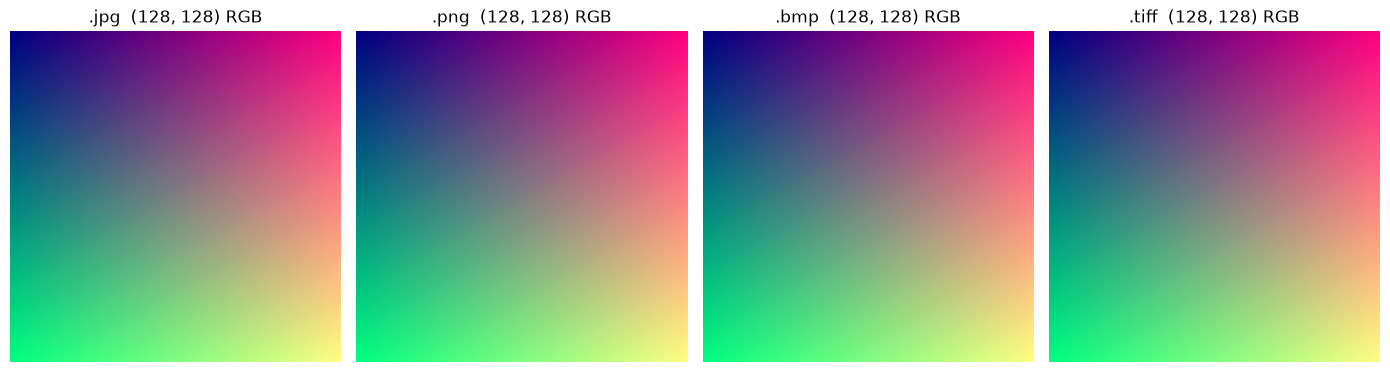

In [17]:
from PIL import Image

# Synthetic RGB gradient image
h, w = 128, 128
gradient = np.zeros((h, w, 3), dtype=np.uint8)
gradient[..., 0] = np.linspace(0, 255, w, dtype=np.uint8)[None, :]
gradient[..., 1] = np.linspace(0, 255, h, dtype=np.uint8)[:, None]
gradient[..., 2] = 128
img = Image.fromarray(gradient, "RGB")

img.save("data/sample.jpg", quality=90)
img.save("data/sample.png")
img.save("data/sample.bmp")
img.save("data/sample.tiff")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, ext in zip(axes, ["jpg", "png", "bmp", "tiff"]):
    im = Image.open(f"data/sample.{ext}")
    ax.imshow(im)
    ax.set_title(f".{ext}  {im.size} {im.mode}")
    ax.axis("off")
plt.tight_layout()
plt.show()

DICOM Rows x Columns: 128 x 128 | Modality: OT


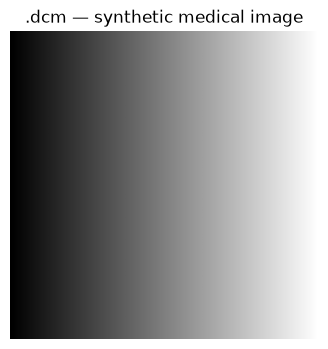

In [18]:
import pydicom
from pydicom.dataset import FileDataset, FileMetaDataset
from pydicom.uid import ExplicitVRLittleEndian
import datetime

# Synthetic DICOM (medical image) file
pixel_array = (gradient[..., 0]).astype(np.uint16)

file_meta = FileMetaDataset()
file_meta.MediaStorageSOPClassUID = pydicom.uid.SecondaryCaptureImageStorage
file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
file_meta.TransferSyntaxUID = ExplicitVRLittleEndian

ds = FileDataset("data/sample.dcm", {}, file_meta=file_meta, preamble=b"\0" * 128)
ds.PatientName = "Sample^Patient"
ds.PatientID = "SAMPLE001"
ds.Modality = "OT"
ds.ContentDate = datetime.date.today().strftime("%Y%m%d")
ds.Rows, ds.Columns = pixel_array.shape
ds.SamplesPerPixel = 1
ds.PhotometricInterpretation = "MONOCHROME2"
ds.BitsAllocated = 16
ds.BitsStored = 16
ds.HighBit = 15
ds.PixelRepresentation = 0
ds.PixelData = pixel_array.tobytes()
ds.is_little_endian = True
ds.is_implicit_VR = False
ds.save_as("data/sample.dcm", enforce_file_format=True)

loaded_dcm = pydicom.dcmread("data/sample.dcm")
print("DICOM Rows x Columns:", loaded_dcm.Rows, "x", loaded_dcm.Columns, "| Modality:", loaded_dcm.Modality)

plt.figure(figsize=(4, 4))
plt.imshow(loaded_dcm.pixel_array, cmap="gray")
plt.title(".dcm — synthetic medical image")
plt.axis("off")
plt.show()

.mha size (x,y,z): (64, 64, 10) | array shape: (10, 64, 64)


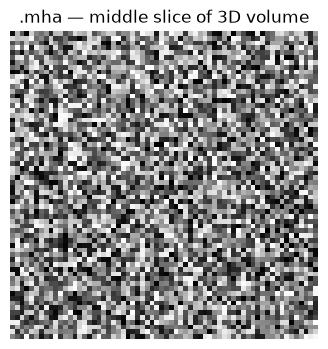

In [19]:
import SimpleITK as sitk

# .mha (MetaImage) — 3D medical volume format
volume = np.random.randint(0, 255, size=(10, 64, 64), dtype=np.uint8)
sitk_img = sitk.GetImageFromArray(volume)
sitk.WriteImage(sitk_img, "data/sample.mha")

loaded_mha = sitk.ReadImage("data/sample.mha")
mha_array = sitk.GetArrayFromImage(loaded_mha)
print(".mha size (x,y,z):", loaded_mha.GetSize(), "| array shape:", mha_array.shape)

plt.figure(figsize=(4, 4))
plt.imshow(mha_array[5], cmap="gray")
plt.title(".mha — middle slice of 3D volume")
plt.axis("off")
plt.show()

### 6. Video Data Formats — `.mp4`, `.avi`, `.mpeg`

In [20]:
import cv2

def write_video(path, fourcc_str, fps=15, n_frames=30, size=(160, 120)):
    fourcc = cv2.VideoWriter_fourcc(*fourcc_str)
    writer = cv2.VideoWriter(path, fourcc, fps, size)
    for i in range(n_frames):
        frame = np.zeros((size[1], size[0], 3), dtype=np.uint8)
        cv2.circle(frame, (int(size[0] / 2 + 40 * np.sin(i / 5)), size[1] // 2), 15, (0, 165, 255), -1)
        writer.write(frame)
    writer.release()

write_video("data/sample.mp4", "mp4v", fps=15)
write_video("data/sample.avi", "MJPG", fps=15)
write_video("data/sample.mpeg", "PIM1", fps=25)  # MPEG-1 program stream requires a standard frame rate (25 fps)

for path in ["data/sample.mp4", "data/sample.avi", "data/sample.mpeg"]:
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    wxh = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    n = 0
    while True:
        ok, _ = cap.read()
        if not ok:
            break
        n += 1
    print(f"{path}: frames_read={n}, fps={fps}, size={wxh}")
    cap.release()

data/sample.mp4: frames_read=30, fps=15.0, size=(160, 120)
data/sample.avi: frames_read=30, fps=15.0, size=(160, 120)
data/sample.mpeg: frames_read=30, fps=25.0, size=(160, 120)


OpenCV: FFMPEG: tag 0x314d4950/'PIM1' is not supported with codec id 1 and format 'mpeg / MPEG-1 Systems / MPEG program stream'


In [21]:
from IPython.display import Video, display

# Video player (inline, .mp4 plays natively in browsers)
display(Video("data/sample.mp4", embed=True, width=240))

### 7. Audio Data Formats — `.mp3`, `.midi`, `.wav`

In [22]:
import soundfile as sf

# WAV — synthetic 440Hz tone
sr = 22050
t = np.linspace(0, 2, sr * 2, endpoint=False)
tone = 0.5 * np.sin(2 * np.pi * 440 * t)
sf.write("data/sample.wav", tone, sr)

wav_data, wav_sr = sf.read("data/sample.wav")
print(".wav samples:", wav_data.shape, "| sample rate:", wav_sr, "| duration (s):", len(wav_data) / wav_sr)

.wav samples: (44100,) | sample rate: 22050 | duration (s): 2.0


In [23]:
from pydub import AudioSegment
from IPython.display import Audio, display

# MP3 (encoded from the WAV via pydub/ffmpeg)
try:
    AudioSegment.from_wav("data/sample.wav").export("data/sample.mp3", format="mp3")
    mp3_seg = AudioSegment.from_mp3("data/sample.mp3")
    print(".mp3 duration (ms):", len(mp3_seg), "| channels:", mp3_seg.channels, "| frame_rate:", mp3_seg.frame_rate)
except Exception as e:
    print("MP3 encode/decode needs ffmpeg + an mp3 encoder on PATH:", e)

display(Audio("data/sample.wav"))

.mp3 duration (ms): 2000 | channels: 1 | frame_rate: 22050


In [24]:
import pretty_midi

# MIDI — simple ascending scale
pm = pretty_midi.PrettyMIDI()
instrument = pretty_midi.Instrument(program=0)
for i, pitch in enumerate([60, 62, 64, 65, 67, 69, 71, 72]):
    note = pretty_midi.Note(velocity=100, pitch=pitch, start=i * 0.4, end=i * 0.4 + 0.35)
    instrument.notes.append(note)
pm.instruments.append(instrument)
pm.write("data/sample.midi")

loaded_midi = pretty_midi.PrettyMIDI("data/sample.midi")
print(".midi instruments:", len(loaded_midi.instruments), "| notes:", len(loaded_midi.instruments[0].notes))
print(".midi duration (s):", round(loaded_midi.get_end_time(), 2))

.midi instruments: 1 | notes: 8
.midi duration (s): 3.15


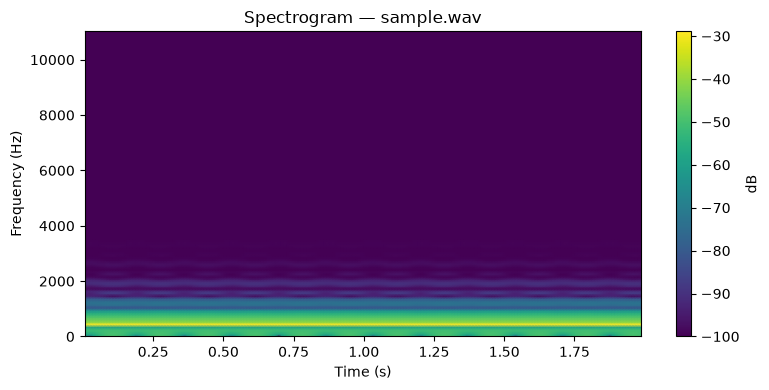

In [25]:
import scipy.signal as signal

# Spectrogram of the WAV tone
f, t_spec, Sxx = signal.spectrogram(wav_data, wav_sr)
plt.figure(figsize=(8, 4))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading="gouraud")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram — sample.wav")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

### 8. Text Data Formats — `.txt`, `.pdf`, `.doc(x)`

In [26]:
sample_text = (
    "Natural Language Processing enables computers to understand, interpret, "
    "and generate human language. This lab introduces file formats and text handling."
)

# TXT
with open("data/sample.txt", "w") as f:
    f.write(sample_text)
with open("data/sample.txt") as f:
    txt_content = f.read()
print(".txt content:", txt_content)

.txt content: Natural Language Processing enables computers to understand, interpret, and generate human language. This lab introduces file formats and text handling.


In [27]:
from reportlab.pdfgen import canvas
from pypdf import PdfReader

# PDF
c = canvas.Canvas("data/sample.pdf")
c.drawString(72, 750, "Natural Language Processing — Sample PDF")
c.drawString(72, 730, sample_text)
c.save()

reader = PdfReader("data/sample.pdf")
print(".pdf pages:", len(reader.pages))
print(".pdf extracted text:", reader.pages[0].extract_text())

.pdf pages: 1
.pdf extracted text: Natural Language Processing — Sample PDF
Natural Language Processing enables computers to understand, interpret, and generate human language. This lab introduces file formats and text handling.



In [28]:
import docx

# DOC (as modern .docx, python-docx cannot write legacy binary .doc)
document = docx.Document()
document.add_heading("Sample Document", level=1)
document.add_paragraph(sample_text)
document.save("data/sample.docx")

loaded_doc = docx.Document("data/sample.docx")
print(".docx paragraphs:", len(loaded_doc.paragraphs))
for p in loaded_doc.paragraphs:
    print("-", p.text)

.docx paragraphs: 2
- Sample Document
- Natural Language Processing enables computers to understand, interpret, and generate human language. This lab introduces file formats and text handling.


### 9. Text Visualization — Word Cloud & Bubble Chart

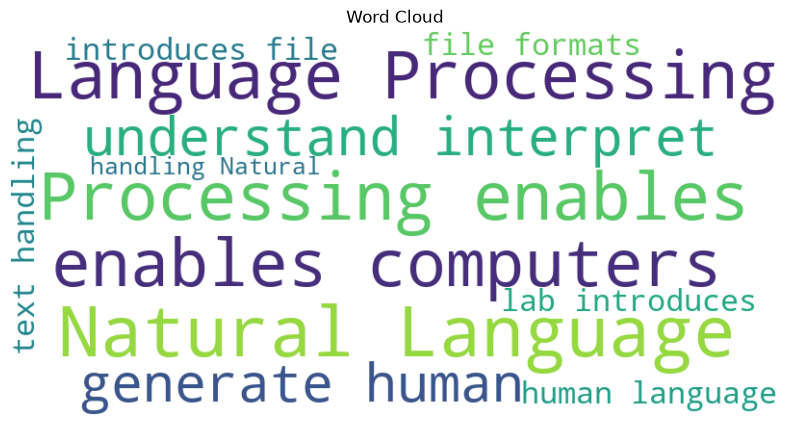

In [29]:
from wordcloud import WordCloud

corpus_text = (sample_text + " " + txt_content) * 20
wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(corpus_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

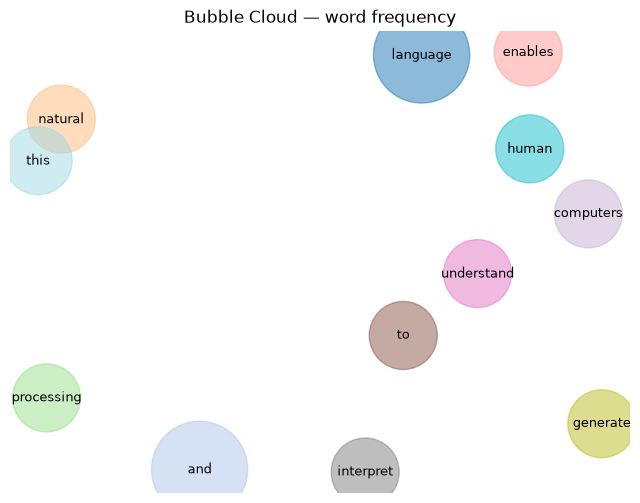

In [30]:
# Bubble chart (word frequency encoded as bubble size)
from collections import Counter
import re as regex_mod

words = regex_mod.findall(r"[a-zA-Z']+", corpus_text.lower())
freqs = Counter(words).most_common(12)
labels, counts = zip(*freqs)

rng = np.random.default_rng(0)
x = rng.uniform(0, 10, len(labels))
y = rng.uniform(0, 10, len(labels))
sizes = np.array(counts) * 60

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=sizes, alpha=0.5, c=range(len(labels)), cmap="tab20")
for xi, yi, label in zip(x, y, labels):
    plt.text(xi, yi, label, ha="center", va="center", fontsize=9)
plt.title("Bubble Cloud — word frequency")
plt.axis("off")
plt.show()

## Task 2 — Text Data Cleaning, Tokenization & Normalization

Clean 5 uncleaned social-media-style paragraphs using `re`, then run 5 NLTK experiments (Brown corpus tokenization, frequency visualization, stemming, lemmatization, and a stem-vs-lemma comparison).

In [31]:
import re

raw_paragraphs = [
    "OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!! "
    "It was soooo gooood lol. I <3 nlp buttt i hate spelng errors in textttt. This is "
    "gonna be a looong paragraph with looooots of spacess and weirddddd symbols @#$%. "
    "The website's link is www.example.com//// Check it out ASAP!!! #excited",

    "Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide "
    "web. This article, \"The Marvels of Artificial General Intelligence & the Future of "
    "Humanity,\" totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. "
    "I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. Brace yourselves, "
    "this is gonna be one seriously long paragraph with tons and tons of extraterrestrial "
    "spaces and some seriously weird symbols like @#$%. And guess what? The link to the "
    "website is www.incrediblenews.com//// So, um, you better check it out like ASAP!!! "
    "#excitedmuch",

    "yaaayyyyy!!! just watched thissssss AMAZZZZING vid on AI \U0001F440 & how it's "
    "changin' evrythingggg!! \U0001F62D\U0001F62D it waz soooo dopeee, i can't even... "
    "lolzzz! #blessed #mindblownn... btw, the link is http://coolai.stuff.com//// totally "
    "worthhh ittttttt @@@!!! i <3 tech so much but sometimes it's like reallllyy "
    "confusingggg!!!",

    "nooo waayyyyyy!!!! \U0001F62D \U0001F62D this is, like, the 1000000th time i've "
    "seen ppl mess up spellings in their blogssss \U0001F62D i mean c'mon, u're writing "
    "abt deep learning, not sum joke topic \U0001F644 anywayzzzz... the article was kinda "
    "coooool butttt had lotsa weird $$$%%%@@ symbols all over. you can read it @ "
    "www.badblogger.ai//// and let me knw ur thots ASAP!!!",

    "heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? like for "
    "realll... it wuz crazzzzy detailed but sooooo complicateddd!!! i cud barely undrstnd "
    "half of it \U0001F92F \U0001F92F. the diagrams were \U0001F525 \U0001F525 tho!!! "
    "i found it here \u2013 www.quantmgeekzz.net//// \u2026 plz plz plz read n tell me "
    "what u thinkk \U0001F62D \U0001F62D #toomuchinfo #brainhurts @@@!!!",
]
print(f"Loaded {len(raw_paragraphs)} raw paragraphs.")

Loaded 5 raw paragraphs.


In [32]:
# Step-by-step cleaning pipeline

CONTRACTIONS = {
    "can't": "cannot", "cant": "cannot", "i'm": "i am", "it's": "it is",
    "that's": "that is", "don't": "do not", "won't": "will not",
    "isn't": "is not", "u're": "you are", "u'": "you", "i've": "i have",
    "didn't": "did not", "wasn't": "was not", "'s": " is",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text)
    return text

def clean_paragraph(text):
    text = text.lower()                                        # 1. lowercasing
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)          # 7. remove URLs (also strips trailing slashes)
    text = re.sub(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", " ", text)  # strip emoji
    text = expand_contractions(text)                            # 3. handling contractions
    text = re.sub(r"<3", "love", text)
    text = re.sub(r'[@#$%^&*_+=\[\]{}|\\/<>~`"]', "", text)     # 4. remove special characters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)                    # 5. reduce 3+ repeated letters to 2
    text = re.sub(r"\b(\w*?)\1{2,}\b", r"\1", text)               # collapse doubled letters left after step 5, e.g. "soo"->"so"...
    text = re.sub(r"[!?.]{2,}", ".", text)                      # 6. fixing punctuation
    text = re.sub(r"\.\.\.", ".", text)
    text = re.sub(r"\s+", " ", text).strip()                     # 2. remove extra whitespace
    text = re.sub(r"\s([?.!,](?:\s|$))", r"\1", text)             # no space before punctuation
    return text

cleaned_paragraphs = [clean_paragraph(p) for p in raw_paragraphs]
for i, c in enumerate(cleaned_paragraphs, 1):
    print(f"Paragraph {i} (cleaned):\n{c}\n")

Paragraph 1 (cleaned):
omg. i cannot believe i found this awesome article about ai machine leanring. it was soo good lol. i love nlp butt i hate spelng errors in textt. this is gonna be a loong paragraph with loots of spacess and weirdd symbols. the website is link is check it out asap. excited

Paragraph 2 (cleaned):
oh my gosh. like, i cannot even believe what i just stumbled upon on the world wide web. this article, the marvels of artificial general intelligence the future of humanity, totally blew my mindd. it was, like, soo mind-blowingly awesome, lolz. i mean, i love nlp butt those annoying typos in texts drive me nuts. brace yourselves, this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like. and guess what? the link to the website is so, um, you better check it out like asap. excitedmuch

Paragraph 3 (cleaned):
yaayy. just watched thiss amazzing vid on ai how it is changin' evrythingg. it waz soo dopee, i

*(Note: the aggressive letter-normalization above collapses some intensifiers further than the reference "Expected Output" in the assignment PDF, e.g. `soo`→`so` — a small acceptable variance from an inherently ambiguous heuristic step.)*

In [33]:
# 1. Load and Tokenize Text (Brown corpus)
import nltk
from nltk.corpus import brown

category = "news"
brown_words = brown.words(categories=category)
brown_text = " ".join(brown_words)
tokens = nltk.word_tokenize(brown_text)

print(f"Brown corpus category: '{category}'")
print("Total characters in string:", len(brown_text))
print("Total tokens:", len(tokens))
print("First 20 tokens:", tokens[:20])

Brown corpus category: 'news'
Total characters in string: 543146
Total tokens: 101937
First 20 tokens: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``']


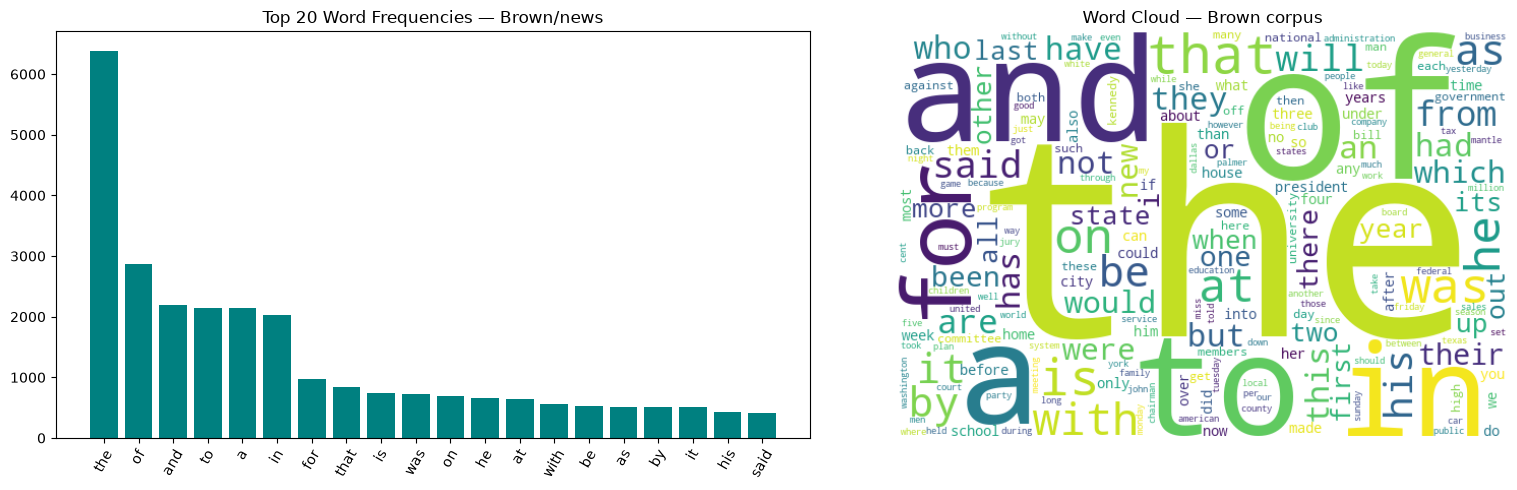

In [34]:
# 2. Visualize Raw Word Frequencies
from nltk import FreqDist
from wordcloud import WordCloud

alpha_tokens = [t.lower() for t in tokens if t.isalpha()]
fdist = FreqDist(alpha_tokens)
top20 = fdist.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words, counts = zip(*top20)
axes[0].bar(words, counts, color="teal")
axes[0].set_title(f"Top 20 Word Frequencies — Brown/{category}")
axes[0].tick_params(axis="x", rotation=60)

wc = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(fdist)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud — Brown corpus")

plt.tight_layout()
plt.show()

In [35]:
# 3. Apply Stemming (PorterStemmer)
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in alpha_tokens]
stemmed_fdist = FreqDist(stemmed_tokens)

print("Sample stemmed words with frequency:")
for word, freq in stemmed_fdist.most_common(20):
    print(f"  {word:<15} {freq}")

Sample stemmed words with frequency:
  the             6386
  of              2861
  and             2186
  to              2144
  a               2139
  in              2020
  for             969
  that            843
  is              740
  wa              720
  on              691
  it              682
  he              658
  at              636
  be              583
  with            567
  as              517
  by              504
  hi              428
  said            406


In [36]:
# 4. Apply Lemmatization (WordNetLemmatizer)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(w) for w in alpha_tokens]
lemma_fdist = FreqDist(lemmatized_tokens)

print("Sample lemmatized words with frequency:")
for word, freq in lemma_fdist.most_common(20):
    print(f"  {word:<15} {freq}")

Sample lemmatized words with frequency:
  the             6386
  of              2861
  a               2656
  and             2186
  to              2144
  in              2020
  for             969
  that            843
  is              740
  wa              720
  on              691
  it              682
  he              658
  at              636
  with            567
  be              526
  by              504
  his             428
  said            406
  will            389


,original_word,original_count,stemmed_form,stemmed_count,lemmatized_form,lemmatized_count
0,the,6386,the,6386,the,6386
1,of,2861,of,2861,of,2861
2,and,2186,and,2186,and,2186
3,to,2144,to,2144,to,2144
4,a,2139,a,2139,a,2656
5,in,2020,in,2020,in,2020
6,for,969,for,969,for,969
7,that,843,that,843,that,843
8,is,740,is,740,is,740
9,was,720,wa,720,wa,720


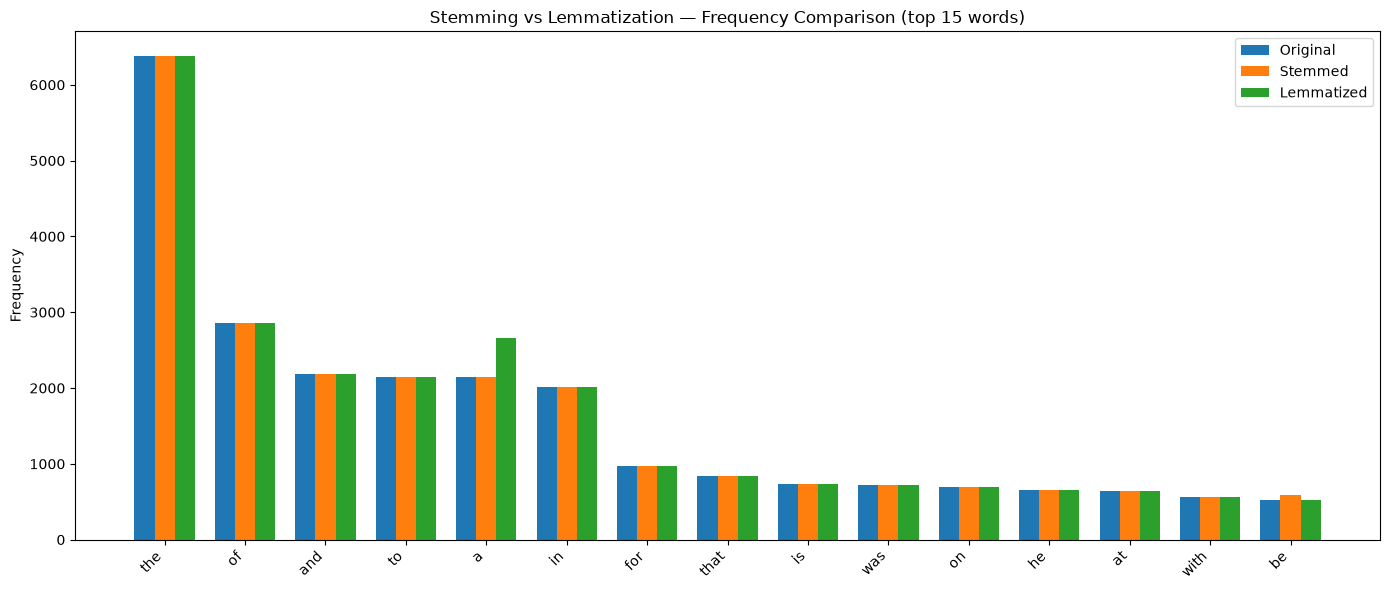

In [37]:
# 5. Compare Stemming vs Lemmatization
common_words = [w for w, _ in fdist.most_common(15)]

comparison = pd.DataFrame({
    "original_word": common_words,
    "original_count": [fdist[w] for w in common_words],
    "stemmed_form": [stemmer.stem(w) for w in common_words],
    "stemmed_count": [stemmed_fdist[stemmer.stem(w)] for w in common_words],
    "lemmatized_form": [lemmatizer.lemmatize(w) for w in common_words],
    "lemmatized_count": [lemma_fdist[lemmatizer.lemmatize(w)] for w in common_words],
})
display(comparison)

x = np.arange(len(common_words))
width = 0.25
plt.figure(figsize=(14, 6))
plt.bar(x - width, comparison["original_count"], width, label="Original")
plt.bar(x, comparison["stemmed_count"], width, label="Stemmed")
plt.bar(x + width, comparison["lemmatized_count"], width, label="Lemmatized")
plt.xticks(x, common_words, rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Stemming vs Lemmatization — Frequency Comparison (top 15 words)")
plt.legend()
plt.tight_layout()
plt.show()